# NB-04: 実測めぐ指数の計算・検証

NB01〜NB03の成果物を統合し、実測めぐ指数（megu_index）を計算する。

## 処理フロー
1. セットアップ・データロード
2. 補正値の計算（ペース補正・馬場補正・クラスパータイム）
3. out_of_range フィルタ
4. 実測めぐ指数の計算
5. 検証
6. 保存

## セクション1: セットアップ・データロード

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---- 入出力パス定義 ----
NB01_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01')
NB02_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02')
NB03_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb03')
OUTPUT_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb04')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('パス設定完了')

パス設定完了


In [2]:
# ---- 入力データ読み込み ----
print('データ読み込み開始...')

# megu_dataset (NB01)
df = pd.read_parquet(NB01_DIR / 'megu_dataset.parquet')
print(f'  megu_dataset: {len(df):,} 行')

# coeff_pace (NB02) - ペース補正係数
coeff_pace = pd.read_parquet(NB02_DIR / 'coeff_pace.parquet')
print(f'  coeff_pace: {len(coeff_pace):,} 行')

# par_time_class (NB02) - クラス別パータイム
par_time_class = pd.read_parquet(NB02_DIR / 'par_time_class.parquet')
print(f'  par_time_class: {len(par_time_class):,} 行')

# delta_track (NB03) - 馬場補正値
delta_track = pd.read_parquet(NB03_DIR / 'delta_track.parquet')
print(f'  delta_track: {len(delta_track):,} 行')

# par_splits (NB01) - 分割タイムパー
par_splits = pd.read_parquet(NB01_DIR / 'par_splits.parquet')
print(f'  par_splits: {len(par_splits):,} 行')

print('データ読み込み完了')

データ読み込み開始...


  megu_dataset: 302,357 行
  coeff_pace: 126 行
  par_time_class: 861 行
  delta_track: 3,721 行
  par_splits: 29 行
データ読み込み完了


In [3]:
# ---- データ概要確認 ----
print('=== megu_dataset カラム一覧 ===')
print(df.dtypes)
print(f'\n行数: {len(df):,}')
print(f'race_id ユニーク数: {df["race_id"].nunique():,}')
print(f'horse_id ユニーク数: {df["horse_id"].nunique():,}')

=== megu_dataset カラム一覧 ===
race_id                  object
date                     object
year                      int64
venue                    object
venue_code               object
surface                  object
distance                  int64
distance_band          category
direction                object
grade                    object
race_class               object
track_condition          object
track_cat                object
weather                  object
field_size                int64
horse_id                 object
horse_number              int64
sex                      object
age_num                   int64
jockey_weight_num       float64
finish_pos                int64
finish_time_raw_sec     float64
finish_time_sec         float64
adjusted_time_sec       float64
last_3f                 float64
front_split_sec         float64
split_point_m           float64
race_t2nd_sec           float64
par_front_split_sec     float64
class_group              object
par_2nd_adj_s

## セクション2: 補正値の計算

In [4]:
# ---- 2-1: class_rank 付与 ----
# NB-01 track_speed.py / NB-02 fit_par_time_class.py と同一の定義を使う。
# 独自の CLASS_RANK_MAP を定義すると NB-02 の par_time_class とキーがずれて
# マージ時に G2/G1 レースへ誤った par_time が当たるため、必ず共通関数を使用すること。
print('class_rank 付与中（NB-01/NB-02 共通定義を使用）...')

from src.pipeline.megu_index.track_speed import assign_class_rank

if 'class_rank' not in df.columns:
    df['class_rank'] = df.apply(
        lambda r: assign_class_rank(r['grade'], r['race_class']), axis=1
    )
    df['class_rank'] = df['class_rank'].fillna(2).astype(int)  # デフォルト: 1勝クラス相当

print('class_rank 分布:')
print(df['class_rank'].value_counts().sort_index())

class_rank 付与中（NB-01/NB-02 共通定義を使用）...


class_rank 分布:
class_rank
1    112181
2    102243
3     40766
4     19909
5     14747
6      6469
7      3448
8      2594
Name: count, dtype: int64


In [5]:
# ---- 2-2: coeff_pace マージ (venue × surface × distance) ----
print('coeff_pace マージ中...')

# coeff_pace のカラム確認
print('coeff_pace カラム:', coeff_pace.columns.tolist())

merge_cols_pace = ['venue', 'surface', 'distance']
df = df.merge(
    coeff_pace[merge_cols_pace + ['coeff_pace']],
    on=merge_cols_pace,
    how='left'
)
pace_merge_rate = df['coeff_pace'].notna().mean()
print(f'coeff_pace マージ率: {pace_merge_rate:.1%}')

coeff_pace マージ中...
coeff_pace カラム: ['venue', 'surface', 'distance', 'coeff_pace', 'n_fit', 'source']


coeff_pace マージ率: 100.0%


In [6]:
# ---- 2-3: front_split_dev 計算 ----
# megu_dataset.parquet には NB-01 §6 で算出した par_front_split_sec が含まれている。
# front_split_dev = 実測前半スプリット − 基準前半スプリット
# この偏差に coeff_pace を乗じることでペース補正量 Δpace を得る。
print('front_split_dev を計算中...')

df['front_split_dev'] = df['front_split_sec'] - df['par_front_split_sec']

# 欠損（front_split_sec 未取得レース等）は 0 補完 → ペース補正なし扱い
df['front_split_dev'] = df['front_split_dev'].fillna(0.0)

cov = df['front_split_sec'].notna().mean()
print(f'  front_split_sec カバレッジ: {cov:.1%}')
print(f'  front_split_dev 統計:')
print(df['front_split_dev'].describe().round(3))
print('front_split_dev 計算完了')

front_split_dev を計算中...
  front_split_sec カバレッジ: 97.7%
  front_split_dev 統計:
count    302357.000
mean         -0.042
std           0.831
min          -6.352
25%          -0.516
50%          -0.025
75%           0.443
max          10.988
Name: front_split_dev, dtype: float64
front_split_dev 計算完了


In [7]:
# ---- 2-4: delta_pace_sec 計算 ----
# delta_pace_sec = coeff_pace × front_split_dev（coeff_pace 欠損 → 0）
print('delta_pace_sec 計算中...')

df['coeff_pace'] = df['coeff_pace'].fillna(0.0)
df['front_split_dev'] = df['front_split_dev'].fillna(0.0)
df['delta_pace_sec'] = df['coeff_pace'] * df['front_split_dev']

print(f'delta_pace_sec 統計:')
print(df['delta_pace_sec'].describe())

delta_pace_sec 計算中...
delta_pace_sec 統計:
count    302357.000000
mean         -0.051760
std           0.649331
min          -4.501784
25%          -0.371350
50%          -0.014342
75%           0.272468
max           7.693249
Name: delta_pace_sec, dtype: float64


In [8]:
# ---- 2-5: delta_track_sec マージ (date × venue × surface) ----
# 欠損 → 0
print('delta_track_sec マージ中...')

print('delta_track カラム:', delta_track.columns.tolist())

merge_cols_track = ['date', 'venue', 'surface']
df = df.merge(
    delta_track[merge_cols_track + ['delta_track_sec']],
    on=merge_cols_track,
    how='left'
)
track_merge_rate = df['delta_track_sec'].notna().mean()
print(f'delta_track_sec マージ率: {track_merge_rate:.1%}')
df['delta_track_sec'] = df['delta_track_sec'].fillna(0.0)
print(f'delta_track_sec 統計:')
print(df['delta_track_sec'].describe())

delta_track_sec マージ中...
delta_track カラム: ['date', 'venue', 'surface', 'delta_track_sec', 'n_races', 'is_fallback']


delta_track_sec マージ率: 100.0%
delta_track_sec 統計:
count    302357.00000
mean          1.53685
std           1.15344
min          -2.41030
25%           0.76500
50%           1.53070
75%           2.24060
max           9.15610
Name: delta_track_sec, dtype: float64


In [9]:
# ---- 2-6: par_time_class_sec マージ (venue × surface × distance × class_rank) ----
print('par_time_class_sec マージ中...')

print('par_time_class カラム:', par_time_class.columns.tolist())

merge_cols_par = ['venue', 'surface', 'distance', 'class_rank']
par_time_col = 'par_time_sec' if 'par_time_sec' in par_time_class.columns else 'par_time_class_sec'
df = df.merge(
    par_time_class[merge_cols_par + [par_time_col]].drop_duplicates(),
    on=merge_cols_par,
    how='left'
)
if par_time_col != 'par_time_class_sec':
    df['par_time_class_sec'] = df[par_time_col]
par_merge_rate = df['par_time_class_sec'].notna().mean()
print(f'par_time_class_sec マージ率: {par_merge_rate:.1%}')

par_time_class_sec マージ中...
par_time_class カラム: ['venue', 'surface', 'distance', 'class_rank', 'par_time_sec', 'alpha', 'beta', 'n_fit', 'source']


par_time_class_sec マージ率: 99.1%


In [10]:
# ---- 2-7: corrected_time 計算 ----
# corrected_time = adjusted_time_sec - delta_pace_sec - delta_track_sec
print('corrected_time 計算中...')

df['corrected_time'] = (
    df['adjusted_time_sec']
    - df['delta_pace_sec']
    - df['delta_track_sec']
)

print(f'corrected_time 統計:')
print(df['corrected_time'].describe())

corrected_time 計算中...
corrected_time 統計:
count    302357.000000
mean        100.371011
std          27.891342
min          50.001886
25%          79.769856
50%          98.439475
75%         114.973362
max         300.433600
Name: corrected_time, dtype: float64


## セクション3: out_of_range フィルタ

In [11]:
print('out_of_range フィルタ適用中...')

# 2着タイムを各レースに付与
time_2nd = (
    df[df['finish_pos'] == 2]
    .groupby('race_id')['adjusted_time_sec']
    .first()
    .rename('time_2nd')
)
df = df.merge(time_2nd, on='race_id', how='left')

# out_of_range 判定
# 3着以下かつ 2着タイムより 2秒以上遅い場合
oor_mask = (
    (df['finish_pos'] > 2)
    & (df['adjusted_time_sec'] > df['time_2nd'] + 2.0)
)

df['computation_status'] = 'valid'
df.loc[oor_mask, 'computation_status'] = 'out_of_range'

status_counts = df['computation_status'].value_counts()
print(f'computation_status 分布:')
print(status_counts)
print(f'\nout_of_range 率: {oor_mask.mean():.1%}')

out_of_range フィルタ適用中...


computation_status 分布:
computation_status
valid           245218
out_of_range     57139
Name: count, dtype: int64

out_of_range 率: 18.9%


## セクション4: 実測めぐ指数の計算

In [12]:
print('実測めぐ指数 計算中...')

# 基準: 50 = 1勝クラス2着馬相当
df['megu_index'] = 50.0 + (df['par_time_class_sec'] - df['corrected_time']) * 10.0

# out_of_range は NULL
df.loc[df['computation_status'] == 'out_of_range', 'megu_index'] = None

# par_time_class_sec が欠損の場合も NULL
df.loc[df['par_time_class_sec'].isna(), 'megu_index'] = None
df.loc[df['par_time_class_sec'].isna(), 'computation_status'] = 'no_par'

# 最終 computation_status 分布
print(f'最終 computation_status 分布:')
print(df['computation_status'].value_counts())

print(f'\nmegu_index 統計:')
print(df['megu_index'].describe())
print(f'megu_index null 率: {df["megu_index"].isna().mean():.1%}')

実測めぐ指数 計算中...
最終 computation_status 分布:
computation_status
valid           242853
out_of_range     56836
no_par            2668
Name: count, dtype: int64

megu_index 統計:
count    242853.000000
mean         55.085687
std          12.253833
min         -64.954378
25%          47.732606
50%          55.724315
75%          63.096957
max         149.230041
Name: megu_index, dtype: float64
megu_index null 率: 19.7%


## セクション5: 検証

=== megu_index 分布（芝/ダート別）===


  芝: 平均=53.5, 中央値=54.3, std=12.2, N=127,623


  ダート: 平均=56.9, 中央値=57.3, std=12.0, N=115,230


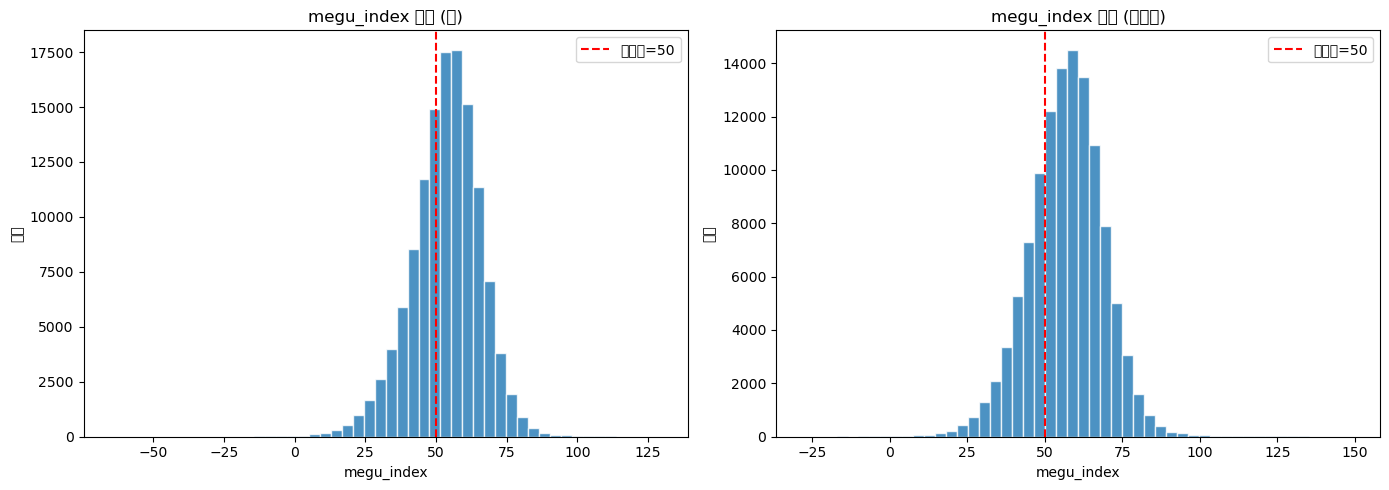

芝/ダート別分布 保存完了


In [13]:
# ---- 5-1: megu_index 分布（芝/ダート別）----
print('=== megu_index 分布（芝/ダート別）===')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, surface_val in zip(axes, ['芝', 'ダート']):
    subset = df[df['surface'] == surface_val]['megu_index'].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=50, edgecolor='white', alpha=0.8)
        ax.axvline(50, color='red', linestyle='--', label='基準値=50')
        ax.set_title(f'megu_index 分布 ({surface_val})')
        ax.set_xlabel('megu_index')
        ax.set_ylabel('頻度')
        ax.legend()
        print(f'  {surface_val}: 平均={subset.mean():.1f}, 中央値={subset.median():.1f}, std={subset.std():.1f}, N={len(subset):,}')
    else:
        ax.set_title(f'データなし ({surface_val})')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'megu_index_distribution_by_surface.png', dpi=100)
plt.show()
print('芝/ダート別分布 保存完了')

=== クラス別 megu_index 統計 ===
             mean  median    std  count
class_rank                             
1           51.82   51.86  11.62  81832
2           55.01   56.27  13.18  84610
3           60.45   60.47   9.58  36639
4           60.09   59.88   9.23  18137
5           55.46   56.05  13.37  12595
6           52.59   53.07  10.46   5858
7           53.92   53.19  12.47   3182

期待値: class_rank=2 (1勝クラス) の平均が約50に近いことを確認


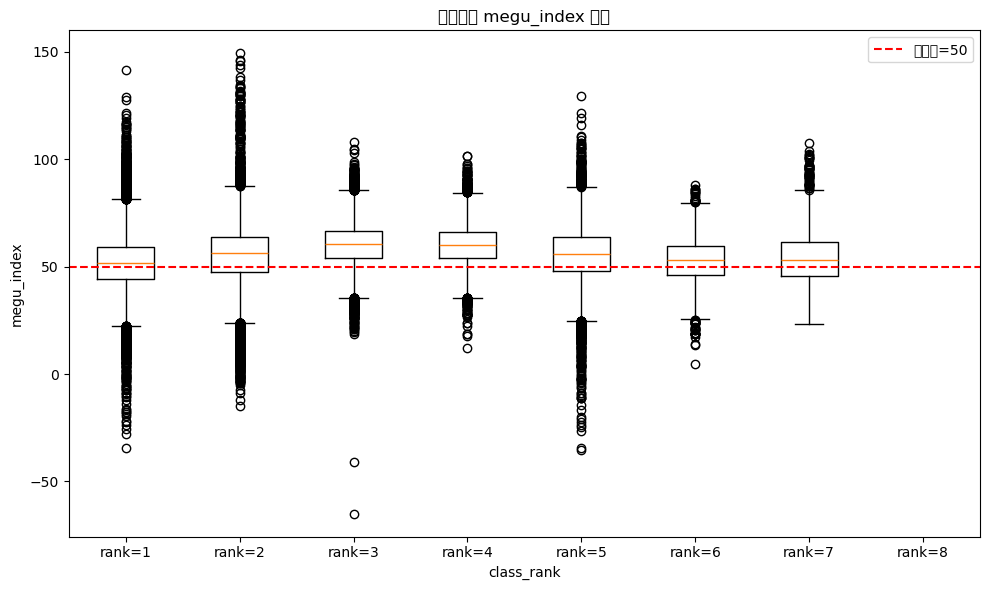

クラス別分布 保存完了


In [14]:
# ---- 5-2: クラス別 megu_index 分布 ----
print('=== クラス別 megu_index 統計 ===')

class_stats = (
    df[df['megu_index'].notna()]
    .groupby('class_rank')['megu_index']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
)
print(class_stats)
print('\n期待値: class_rank=2 (1勝クラス) の平均が約50に近いことを確認')

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [df[df['class_rank'] == r]['megu_index'].dropna().values
     for r in sorted(df['class_rank'].unique())],
    labels=[f'rank={r}' for r in sorted(df['class_rank'].unique())]
)
ax.axhline(50, color='red', linestyle='--', label='基準値=50')
ax.set_title('クラス別 megu_index 分布')
ax.set_xlabel('class_rank')
ax.set_ylabel('megu_index')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'megu_index_by_class.png', dpi=100)
plt.show()
print('クラス別分布 保存完了')

=== computation_status 件数 ===
computation_status
valid           242853
out_of_range     56836
no_par            2668
Name: count, dtype: int64

合計: 302,357 行


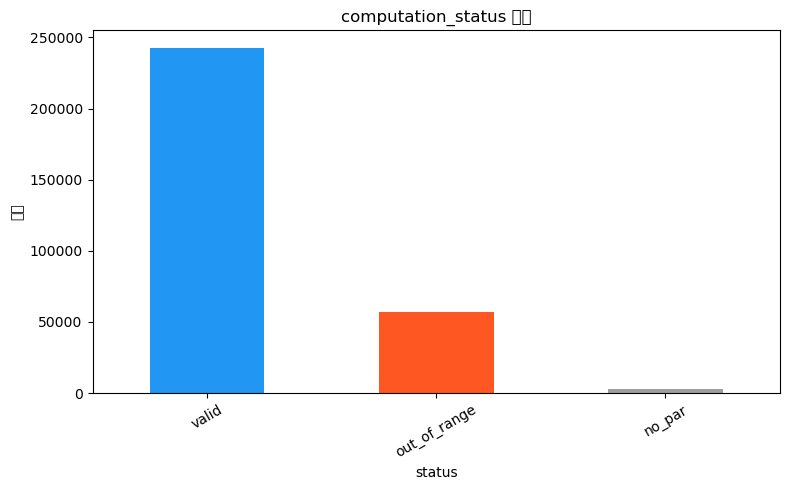

In [15]:
# ---- 5-3: valid / out_of_range / no_par の件数確認 ----
print('=== computation_status 件数 ===')
status_detail = df['computation_status'].value_counts()
print(status_detail)
print(f'\n合計: {len(df):,} 行')

fig, ax = plt.subplots(figsize=(8, 5))
status_detail.plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722', '#9E9E9E'])
ax.set_title('computation_status 件数')
ax.set_xlabel('status')
ax.set_ylabel('件数')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'computation_status_counts.png', dpi=100)
plt.show()

=== 年別 megu_index 分布 ===
       mean  median    std  count
year                             
2020  55.40   56.08  12.47  38029
2021  54.98   55.71  12.44  38007
2022  54.93   55.47  12.02  37560
2023  55.18   55.94  12.28  37500
2024  55.15   55.77  12.15  37041
2025  55.11   55.69  12.10  37904
2026  54.58   55.01  12.33  16812


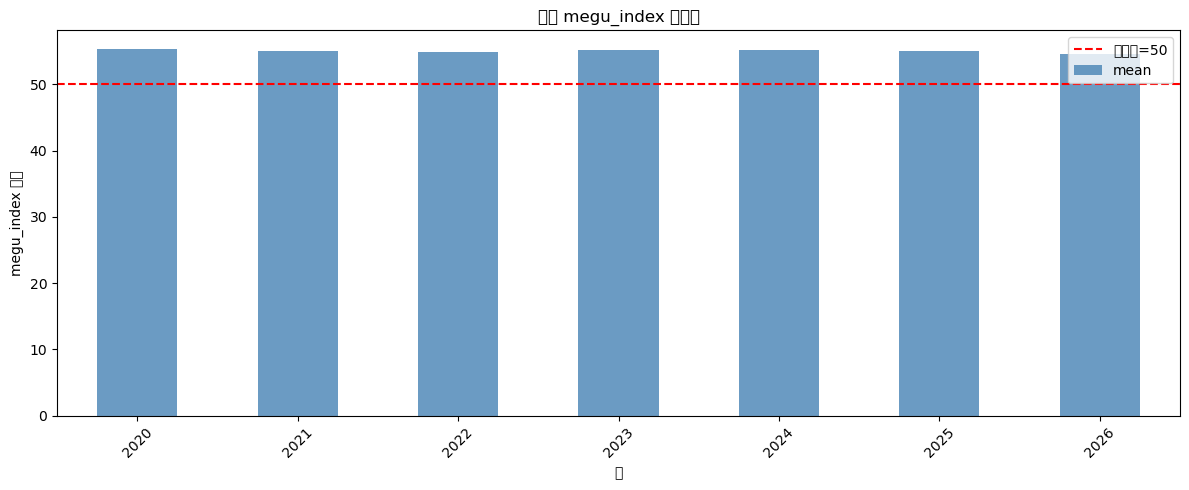

年別分布 保存完了


In [16]:
# ---- 5-4: 年別の分布確認 ----
print('=== 年別 megu_index 分布 ===')

df['year'] = pd.to_datetime(df['date']).dt.year
year_stats = (
    df[df['megu_index'].notna()]
    .groupby('year')['megu_index']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
)
print(year_stats)

fig, ax = plt.subplots(figsize=(12, 5))
year_stats['mean'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.axhline(50, color='red', linestyle='--', label='基準値=50')
ax.set_title('年別 megu_index 平均値')
ax.set_xlabel('年')
ax.set_ylabel('megu_index 平均')
ax.legend()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'megu_index_by_year.png', dpi=100)
plt.show()
print('年別分布 保存完了')

## セクション6: 保存

In [17]:
# ---- 出力スキーマに合わせてカラムを選択 ----
output_cols = [
    'race_id', 'horse_id', 'date', 'venue', 'surface', 'distance',
    'class_rank', 'finish_pos', 'adjusted_time_sec',
    'delta_pace_sec', 'delta_track_sec', 'corrected_time',
    'par_time_class_sec', 'megu_index', 'computation_status'
]

# 存在するカラムのみ選択
available_cols = [c for c in output_cols if c in df.columns]
missing_cols = [c for c in output_cols if c not in df.columns]
if missing_cols:
    print(f'警告: 以下のカラムが存在しません: {missing_cols}')

df_out = df[available_cols].copy()

# 型変換
df_out['race_id'] = df_out['race_id'].astype(str)
df_out['horse_id'] = df_out['horse_id'].astype(str)
df_out['date'] = df_out['date'].astype(str)
df_out['distance'] = df_out['distance'].astype(int)
df_out['class_rank'] = df_out['class_rank'].astype(int)

print(f'出力データ: {len(df_out):,} 行 × {len(df_out.columns)} 列')
print(df_out.dtypes)

出力データ: 302,357 行 × 15 列
race_id                object
horse_id               object
date                   object
venue                  object
surface                object
distance                int64
class_rank              int64
finish_pos              int64
adjusted_time_sec     float64
delta_pace_sec        float64
delta_track_sec       float64
corrected_time        float64
par_time_class_sec    float64
megu_index            float64
computation_status     object
dtype: object


In [18]:
# ---- megu_index.parquet 保存 ----
output_path = OUTPUT_DIR / 'megu_index.parquet'
df_out.to_parquet(output_path, index=False)
print(f'megu_index.parquet 保存完了: {output_path}')
print(f'  行数: {len(df_out):,}')
print(f'  valid 件数: {(df_out["computation_status"] == "valid").sum():,}')
print(f'  megu_index null 率: {df_out["megu_index"].isna().mean():.1%}')

# 読み込み検証
verify = pd.read_parquet(output_path)
print(f'\n検証読み込み OK: {len(verify):,} 行')
print('NB-04 処理完了')

megu_index.parquet 保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb04/megu_index.parquet
  行数: 302,357
  valid 件数: 242,853
  megu_index null 率: 19.7%

検証読み込み OK: 302,357 行
NB-04 処理完了
